In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

import gps
import gps_sim
import prn

# Carrier Tracking

In [172]:
f_s = 2.6e6
f_if = 5.123e3
sv = 1

samples = gps_sim.generate_gps(
    f_s=f_s,
    n=int(f_s * 4),
    sv=sv,
    doppler=f_if,
    doppler2=2,
    code_phase=300,
    signal_power=-130,
)

In [173]:
# Acquisition

results = gps.acquisition(samples, f_s, 10e3, 500, sv=sv)
code_est = results[0][2]
freq_est = gps.fine_acquisition(samples, f_s, 8192, 8, sv, code_est)

print(code_est, freq_est)

763 5138.261506531533


In [175]:
carrier_pll = gps.PLL(6.5, 0.707, 0.25, 1e-3)
code_dll = gps.PLL(1, 0.707, 1, 1e-3)

# Parameters
ms_count = int(1e3 * len(samples) / f_s)
code_freq_basis = 1.023e6
early_late_spacing = 0.5

code_ref = prn.generate(sv)
code_ref = [code_ref[-1]] + code_ref + [code_ref[0]]
code_ref = np.array(code_ref)

# Variables
carrier_phase = 0
carrier_freq = freq_est

code_phase = 0 # units of code chips
code_freq = code_freq_basis

# sample_position = code_est # units of samples
sample_position = int(f_s/1e3 - code_est)

# Outputs
res_carr_freq = []
res_carr_err = []
res_code_freq = []
res_code_err = []
res_code_phase = []
res_iq = []

for t_ms in range(ms_count):
    code_phase_step = code_freq / f_s
    blksize = int(np.ceil((1023 - code_phase) / code_phase_step))

    # Get chunk of data
    raw_signal = samples[sample_position:sample_position + blksize]
    sample_position = sample_position + blksize

    # Exit if not enough samples
    if len(raw_signal) < blksize:
        break

    # Generate code replicas
    tcode = code_phase + np.arange(blksize, dtype=float)*code_phase_step
    prompt_code = code_ref[np.ceil(tcode).astype(int)]

    tcode_early = np.ceil(tcode - early_late_spacing).astype(int)
    early_code = code_ref[tcode_early]

    tcode_late = np.ceil(tcode + early_late_spacing).astype(int)
    late_code = code_ref[tcode_late]

    code_phase = tcode[-1] + code_phase_step - 1023

    # Advance phase
    t = np.arange(blksize + 1) / f_s
    phase = carrier_freq * 2 * np.pi * t + carrier_phase
    carrier_phase = phase[-1] % (2 * np.pi)

    # Shift to DC, remove PRN, and sum
    baseband = raw_signal * np.exp(-1j * phase[:-1])

    prompt = np.sum(baseband * prompt_code)
    early = np.sum(baseband * early_code)
    late = np.sum(baseband * late_code)

    # Update carrier PLL
    carrier_err = np.arctan(prompt.imag / prompt.real) / (2 * np.pi)
    carrier_freq = freq_est + carrier_pll.update(carrier_err)

    # Update code DLL
    code_err = (np.abs(early) - np.abs(late)) / (np.abs(early) + np.abs(late))
    code_freq = code_freq_basis - code_dll.update(code_err)

    # Save stuff for graphing and debugging
    res_carr_freq.append(carrier_freq)
    res_carr_err.append(carrier_err)
    res_iq.append(prompt)

    res_code_freq.append(code_freq)
    res_code_err.append(code_err)
    res_code_phase.append(code_phase)

res_iq = np.array(res_iq, dtype=np.complex64)

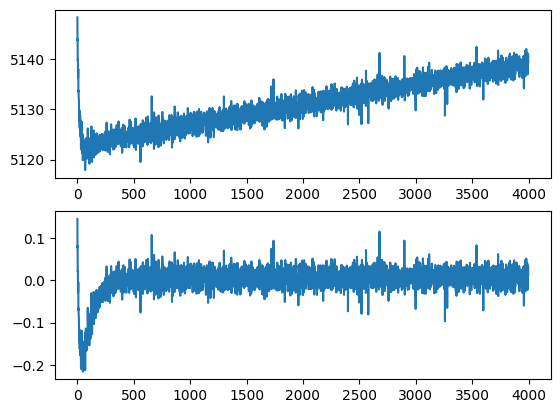

In [177]:
plt.subplot(2, 1, 1)
plt.plot(res_carr_freq)
plt.subplot(2, 1, 2)
plt.plot(res_carr_err)

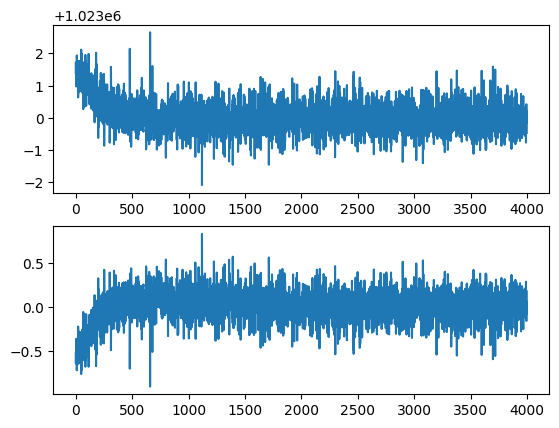

In [178]:
plt.subplot(2, 1, 1)
plt.plot(res_code_freq)
plt.subplot(2, 1, 2)
plt.plot(res_code_err)

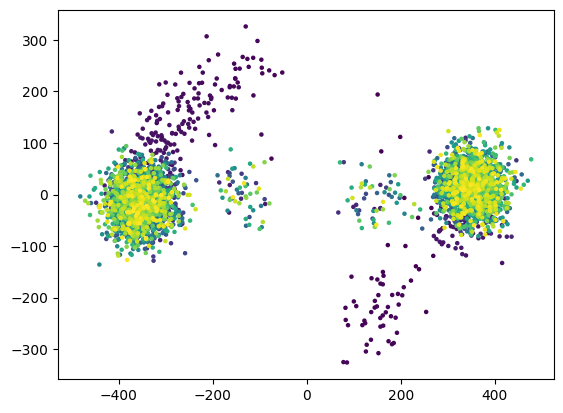

In [179]:
plt.scatter(res_iq.real, res_iq.imag, s=5, c=np.arange(len(res_iq)))